<a href="https://colab.research.google.com/github/mohammadabuhamed2/binx_mohammadabuhamed/blob/main/rnn_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 — RNNs & LSTMs for Sequential Data

## Load the ECG Heartbeat Dataset

### Download the Dataset from Kaggle

In [3]:
import kagglehub
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print(path)

100%|██████████| 98.8M/98.8M [00:03<00:00, 31.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1


### Check Dataset Files

In [54]:
import os
print(os.listdir(path))

['ptbdb_abnormal.csv', 'ptbdb_normal.csv', 'mitbih_test.csv', 'mitbih_train.csv']


### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

### Set Dataset File Paths

In [4]:
train_file = path + "/mitbih_train.csv"
test_file = path + "/mitbih_test.csv"

### Load the Training and Test Data

In [5]:
train_df = pd.read_csv(train_file, header=None)
test_df = pd.read_csv(test_file,header=None)

### Check Dataset Shape

In [58]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


### Preview the Dataset

In [59]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Prepare Features and Labels

### Separate ECG Signals and Labels

In [6]:
X_train = train_df.drop(columns=187)
y_train = train_df[187]
X_test = test_df.drop(columns=187)
y_test = test_df[187]

### Check Features and Labels Shape

In [7]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (87554, 187)
y_train shape: (87554,)
X_test shape: (21892, 187)
y_test shape: (21892,)


In [62]:
print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts(normalize=True)*100)

187
0.0    82.772917
4.0     7.345181
2.0     6.610777
1.0     2.539005
3.0     0.732120
Name: proportion, dtype: float64
187
0.0    82.760826
4.0     7.345149
2.0     6.614288
1.0     2.539741
3.0     0.739996
Name: proportion, dtype: float64


### Class Distribution Analysis

The dataset is highly imbalanced.

- **Class 0:** 82.77%
- **Class 4:** 7.35%
- **Class 2:** 6.61%
- **Class 1:** 2.54%
- **Class 3:** 0.73%

Most of the samples belong to Class 0, while the other classes contain much fewer samples.

Because of this imbalance, accuracy alone may not be enough to evaluate the model. Additional metrics such as recall and the confusion matrix should also be considered.

## Visualize ECG Heartbeat Signals

### Plot ECG Samples from Different Classes

In [63]:
sample_0 = X_train.loc[y_train[y_train == 0].index[0]]
sample_1 = X_train.loc[y_train[y_train == 1].index[0]]
sample_2 = X_train.loc[y_train[y_train == 2].index[0]]
sample_3 = X_train.loc[y_train[y_train == 3].index[0]]
sample_4 = X_train.loc[y_train[y_train == 4].index[0]]

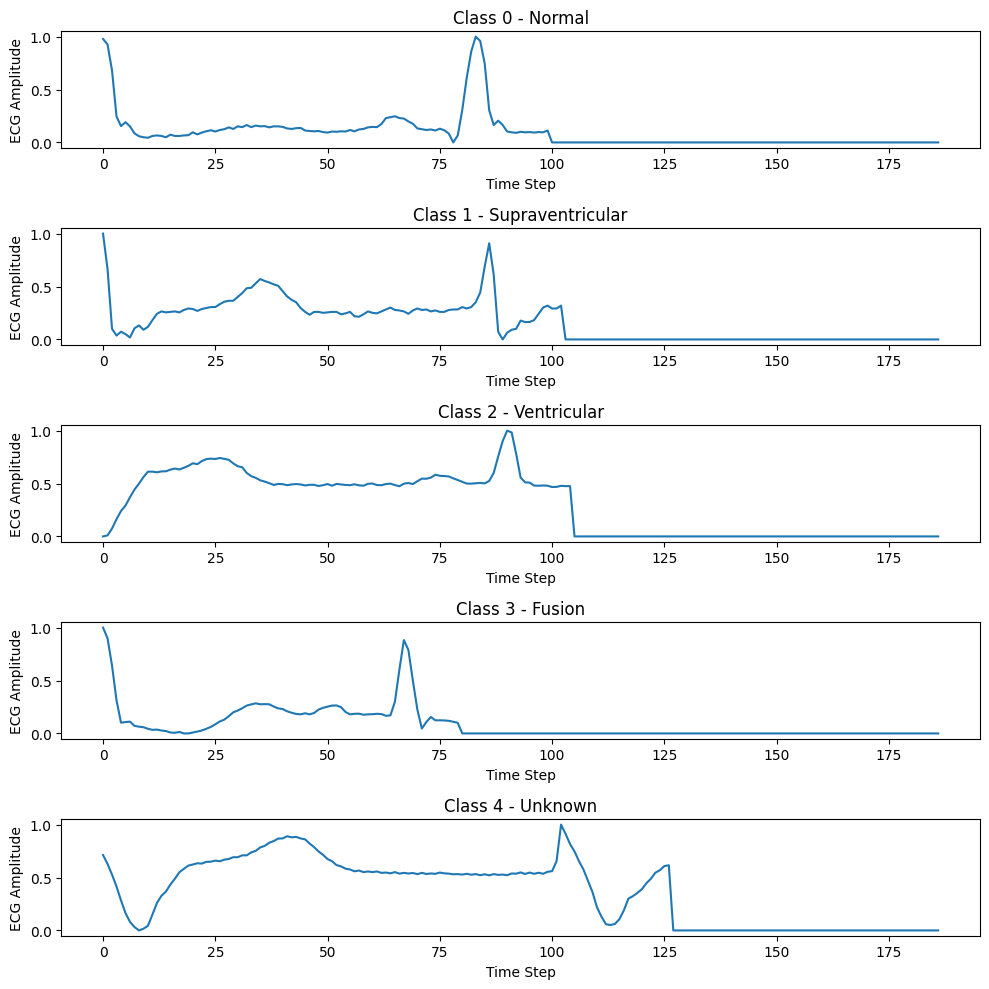

In [64]:
fig, axes = plt.subplots(5, 1, figsize=(10, 10))

axes[0].plot(sample_0.values)
axes[0].set_title("Class 0 - Normal")

axes[1].plot(sample_1.values)
axes[1].set_title("Class 1 - Supraventricular")

axes[2].plot(sample_2.values)
axes[2].set_title("Class 2 - Ventricular")

axes[3].plot(sample_3.values)
axes[3].set_title("Class 3 - Fusion")

axes[4].plot(sample_4.values)
axes[4].set_title("Class 4 - Unknown")

for ax in axes:
    ax.set_xlabel("Time Step")
    ax.set_ylabel("ECG Amplitude")

plt.tight_layout()
plt.show()

### ECG Signal Comparison

The ECG heartbeat signals show different patterns across the five classes.

Each class has a different waveform shape and timing pattern, which helps the model distinguish between heartbeat types.

Because the order of the ECG values represents the signal over time, the sequence must be preserved during training.

The zero values at the end of some samples represent padding used to make all heartbeat sequences have the same length.

## Reshape Data for LSTM

### Convert ECG Signals to 3D Sequences

LSTM layers expect input in the form:

`(samples, time steps, features)`

Each ECG sample contains 187 time steps, and each time step has one feature: the ECG amplitude.

Therefore, the data is reshaped from `(samples, 187)` to `(samples, 187, 1)`.

In [8]:
X_train = X_train.values.reshape(-1, 187, 1)
X_test = X_test.values.reshape(-1, 187, 1)

In [9]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (87554, 187, 1)
X_test shape: (21892, 187, 1)


## Step 1: Build and Train an LSTM Model

### Build the LSTM Model

In [77]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(187, 1)),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(5, activation="softmax")
])

### Display the Model Architecture

In [78]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,221 (67.27 KB)

 Trainable params: 17,221 (67.27 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the LSTM Model

In [79]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Configure Early Stopping

In [80]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Configure Model Checkpoint

In [76]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/binx_training/day3_week7/best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True
)

### Create a Stratified Validation Set

In [21]:
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [22]:
y_train_new = y_train_new.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

### Train the LSTM Model

In [83]:
history = model.fit(
    X_train_new,
    y_train_new,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 195s 88ms/step - accuracy: 0.8278 - loss: 0.6584 - val_accuracy: 0.8277 - val_loss: 0.6417
Epoch 2/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 199s 86ms/step - accuracy: 0.8277 - loss: 0.6458 - val_accuracy: 0.8277 - val_loss: 0.6380
Epoch 3/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 190s 87ms/step - accuracy: 0.8279 - loss: 0.6362 - val_accuracy: 0.8277 - val_loss: 0.6433
Epoch 4/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 189s 87ms/step - accuracy: 0.8277 - loss: 0.6429 - val_accuracy: 0.8277 - val_loss: 0.6531
Epoch 5/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 190s 87ms/step - accuracy: 0.8276 - loss: 0.6427 - val_accuracy: 0.8279 - val_loss: 0.6304
Epoch 6/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 190s 87ms/step - accuracy: 0.8300 - loss: 0.6158 - val_accuracy: 0.8277 - val_loss: 0.6405
Epoch 7/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 202s 87ms/step - accuracy: 0.8615 - loss: 0.4711 - val_accuracy: 0.8880 - val_loss: 0.3908
Epoch 8/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 188s 86ms/step - ac

### i have disconnected

### Load the Saved LSTM Model

In [11]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/binx_training/day3_week7/best_lstm_model.keras"
)

### Evaluate the LSTM Model

In [12]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

685/685 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9754 - loss: 0.0905
Test Loss: 0.09046328812837601
Test Accuracy: 0.9753791093826294


### LSTM Test Results

The LSTM model achieved strong performance on the test dataset.

- **Test Accuracy:** 97.54%
- **Test Loss:** 0.0905

Although the overall accuracy is high, the dataset is imbalanced, so additional evaluation metrics are needed to measure the model's performance across all heartbeat classes.

### Generate LSTM Predictions

In [13]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

685/685 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step


### Classification Report

In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     18118
         1.0       0.92      0.59      0.72       556
         2.0       0.93      0.92      0.92      1448
         3.0       0.72      0.73      0.72       162
         4.0       0.99      0.96      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.91      0.84      0.87     21892
weighted avg       0.97      0.98      0.97     21892



### Classification Report Analysis

The LSTM achieved strong overall performance, but its performance varied across the heartbeat classes.

- Class 0 achieved almost perfect recall.
- Classes 2 and 4 also achieved strong precision, recall, and F1-score.
- Class 1 had the lowest recall at 59%, meaning many samples from this class were misclassified.
- Class 3 achieved moderate performance with a recall of 73%.

The difference between the macro average and weighted average shows the effect of class imbalance. The weighted scores are higher because Class 0 contains most of the samples.

Therefore, the model performs very well overall, but the minority classes still require more attention.

### Confusion Matrix

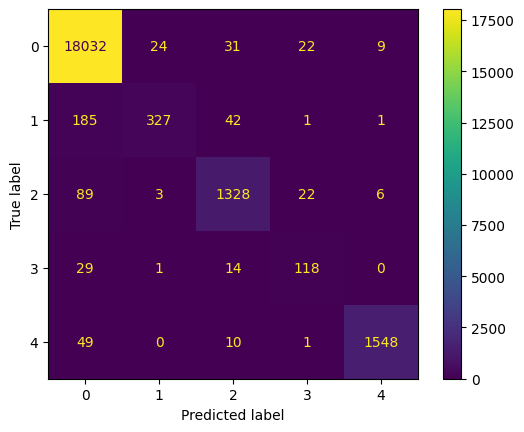

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0, 1, 2, 3, 4])
disp.plot()
plt.show()

### Confusion Matrix Analysis

The confusion matrix compares the true heartbeat classes with the classes predicted by the LSTM model.

Most correct predictions appear on the main diagonal of the matrix.

- Class 0 was classified very accurately, with 18,032 correct predictions.
- Class 1 had the weakest performance. Many Class 1 samples were incorrectly predicted as Class 0.
- Class 2 achieved strong performance with 1,328 correct predictions.
- Class 3 showed moderate performance, with some samples confused with Classes 0 and 2.
- Class 4 was classified very accurately, with 1,548 correct predictions.

The confusion matrix confirms that the model performs very well overall, but the minority classes, especially Class 1 and Class 3, are more difficult for the model to classify correctly.

## Step 2: Build and Train a Simple RNN Model

In [16]:
rnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(187, 1)),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dense(5, activation="softmax")
])

### Compile the Simple RNN Model

In [17]:
rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Configure RNN Early Stopping

In [18]:
rnn_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

### Configure RNN Model Checkpoint

In [19]:
rnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/binx_training/day3_week7/best_rnn_model.keras",
    monitor="val_loss",
    save_best_only=True
)

### Train the Simple RNN Model

In [23]:
rnn_history = rnn_model.fit(
    X_train_new,
    y_train_new,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[rnn_early_stopping, rnn_checkpoint]
)

Epoch 1/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 90s 41ms/step - accuracy: 0.8250 - loss: 0.6634 - val_accuracy: 0.8277 - val_loss: 0.6578
Epoch 2/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 88s 40ms/step - accuracy: 0.8278 - loss: 0.6559 - val_accuracy: 0.8282 - val_loss: 0.6507
Epoch 3/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 145s 42ms/step - accuracy: 0.8276 - loss: 0.6565 - val_accuracy: 0.8279 - val_loss: 0.6501
Epoch 4/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 86s 39ms/step - accuracy: 0.8264 - loss: 0.6569 - val_accuracy: 0.8279 - val_loss: 0.6432
Epoch 5/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 88s 40ms/step - accuracy: 0.8278 - loss: 0.6585 - val_accuracy: 0.8277 - val_loss: 0.6580
Epoch 6/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 85s 39ms/step - accuracy: 0.8278 - loss: 0.6436 - val_accuracy: 0.8281 - val_loss: 0.6322
Epoch 7/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 91s 42ms/step - accuracy: 0.8281 - loss: 0.6290 - val_accuracy: 0.8287 - val_loss: 0.6260
Epoch 8/200
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 101s 46ms/step - accuracy

### Evaluate the Simple RNN Model

In [24]:
rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(
    X_test,
    y_test
)
print("RNN Test Loss:", rnn_test_loss)
print("RNN Test Accuracy:", rnn_test_accuracy)

685/685 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8297 - loss: 0.5293
RNN Test Loss: 0.5293067097663879
RNN Test Accuracy: 0.8296638131141663


### RNN Test Results

The Simple RNN achieved lower performance than the LSTM model.

- **RNN Test Accuracy:** 82.97%
- **RNN Test Loss:** 0.5293

Compared with the LSTM, the Simple RNN had lower accuracy and a higher loss.

This suggests that the LSTM was better at learning the sequential patterns in the ECG heartbeat signals.

### LSTM vs Simple RNN Comparison

| Model | Test Accuracy | Test Loss |
|---|---:|---:|
| LSTM | 97.54% | 0.0905 |
| Simple RNN | 82.97% | 0.5293 |

The LSTM achieved significantly better performance than the Simple RNN.

It obtained higher test accuracy and much lower test loss, showing that the LSTM was more effective at learning the sequential patterns in the ECG heartbeat data.

### Generate RNN Predictions

In [25]:
rnn_pred_prob = rnn_model.predict(X_test)
rnn_pred = np.argmax(rnn_pred_prob, axis=1)

685/685 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step


### RNN Classification Report

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test,rnn_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91     18118
           1       0.57      0.01      0.01       556
           2       0.80      0.03      0.06      1448
           3       0.00      0.00      0.00       162
           4       0.00      0.00      0.00      1608

    accuracy                           0.83     21892
   macro avg       0.44      0.21      0.20     21892
weighted avg       0.75      0.83      0.76     21892



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Simple RNN Classification Report Analysis

The Simple RNN performed poorly on the minority heartbeat classes despite achieving an overall accuracy of about 83%.

- Class 0 achieved nearly perfect recall because it represents most of the dataset.
- Class 1 and Class 2 had very low recall.
- Class 3 and Class 4 had zero recall, meaning the model failed to correctly identify these classes.
- The high overall accuracy is therefore misleading because of the strong class imbalance.

The results show that the Simple RNN mainly learned to predict the majority class and struggled to learn the patterns of the minority classes.

### LSTM vs Simple RNN — Recall Comparison

| Class | LSTM Recall | Simple RNN Recall |
|---|---:|---:|
| Class 0 | 1.00 | 1.00 |
| Class 1 | 0.59 | 0.01 |
| Class 2 | 0.92 | 0.03 |
| Class 3 | 0.73 | 0.00 |
| Class 4 | 0.96 | 0.00 |

The LSTM performed much better than the Simple RNN on the minority classes.

The Simple RNN mainly learned to predict Class 0, which is the majority class, while it almost completely failed to identify Classes 1, 2, 3, and 4.

The LSTM was able to learn the sequential ECG patterns much more effectively across all heartbeat classes.

## Step 3: Why Order Awareness Helped

ECG data is sequential because each value represents the heart signal at a specific point in time.

The order of these values is important because the complete heartbeat pattern is formed by how the signal changes over time.

The LSTM processes the ECG sequence in order and uses its memory to keep relevant information from earlier time steps.

This allows the model to learn temporal patterns across the heartbeat signal.

The Simple RNN also processes the sequence in order, but it struggles to preserve information across longer sequences because of the vanishing gradient problem.

The LSTM uses gated memory to retain important information for longer periods, which helped it achieve much better performance on this dataset.